In [1]:
%matplotlib inline
import importlib
from md_engine import MDSimulation, SimulationConfig
import numpy as np
import matplotlib.pyplot as plt
from scipy.constants import Boltzmann
import scipy as sp

In [2]:
# default configuration for the simulation

sim = MDSimulation.load_yaml("simulation_config.yaml")

if __name__ == "__main__":
    result = sim.run(output_dir=None,run_diag=False,plot_msd=False,plot_rdf=False,to_save=False)


System: N = 256 atoms, L = 6.7184 σ
ε/k_B = 162.5467 K   (ε = 1.4000e-02 eV,  k_B = 1.380649e-23 J/K)
T* values: [0.01, 0.2, 0.4, 0.6, 0.8, 1.0]
Equivalent T (K): [1.625, 32.509, 65.019, 97.528, 130.037, 162.547]
Launching 6 tasks across 6 workers...

  [T* = 0.400 | T = 65.02 K]  equilibrating (2000 steps)...  [T* = 0.600 | T = 97.53 K]  equilibrating (2000 steps)...  [T* = 0.200 | T = 32.51 K]  equilibrating (2000 steps)...  [T* = 0.010 | T = 1.63 K]  equilibrating (2000 steps)...

  [T* = 0.800 | T = 130.04 K]  equilibrating (2000 steps)...

  [T* = 1.000 | T = 162.55 K]  equilibrating (2000 steps)...

  [T* = 0.010] Equilibration:   0% (1/2000) — elapsed: 00:00:00  [T* = 0.800] Equilibration:   0% (1/2000) — elapsed: 00:00:00  [T* = 0.200] Equilibration:   0% (1/2000) — elapsed: 00:00:00  [T* = 0.400] Equilibration:   0% (1/2000) — elapsed: 00:00:00

  [T* = 0.600] Equilibration:   0% (1/2000) — elapsed: 00:00:00

  [T* = 1.000] Equilibration:   0% (1/2000) — elapsed: 00:00:00

  

## Pressure calcs

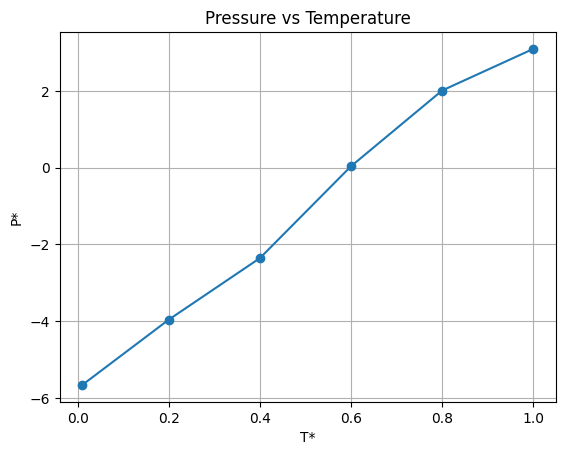

In [ ]:
def get_pressure(r,g_r,rho_star,T_star,sim,LRC=False):
    r_squared = r**2
    _,forces = sim._calculate_lennard_jones_properties(r_squared,SimulationConfig.r_cutoff**2)
    forces[r > SimulationConfig.r_cutoff] = 0.0

    integral = sp.integrate.simpson(forces*r_squared**2*g_r, x=r)
    P_star = rho_star*T_star + (2.0/3)*np.pi*rho_star**2*integral

    P_star_LRC = (32.0/9)*np.pi*rho_star**2*(SimulationConfig.r_cutoff**(-9)) - (16.0/3)*np.pi*rho_star**2*(SimulationConfig.r_cutoff**(-3))

    if LRC:
        return P_star + P_star_LRC
    else:
        return P_star


P_star = []
rho_star = SimulationConfig.rho_star
for i in range(len(result)):
    r = result[i].r_centers
    g_r = result[i].g_avg
    T_star = result[i].T_star
    P_star.append(get_pressure(r,g_r,rho_star,T_star,sim))

T_stars = [res.T_star for res in result]
plt.plot(T_stars, P_star, marker='o')
plt.xlabel('T*')
plt.ylabel('P*')
plt.title('Pressure vs Temperature')
plt.grid()
plt.show()

## Internal energy calcs

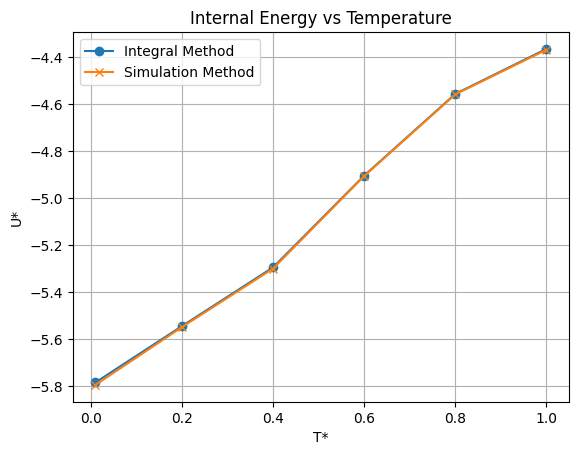

In [ ]:
g_r = result[-1].g_avg
r = result[-1].r_centers
rho_star = SimulationConfig.rho_star

def get_internal_energy(g_r, r, rho_star,sim,LRC = False):
    potential_energy, _ = sim._calculate_lennard_jones_properties(r**2, SimulationConfig.r_cutoff**2)
    potential_energy[r > SimulationConfig.r_cutoff] = 0.0

    integral = sp.integrate.simpson(potential_energy*g_r*r**2, x=r)
    U_star = 2*np.pi*rho_star*integral

    U_star_LRC = (8.0/9)*np.pi*rho_star*(SimulationConfig.r_cutoff**(-9)) - (8.0/3)*np.pi*rho_star*(SimulationConfig.r_cutoff**(-3))

    if LRC:
        return U_star + U_star_LRC
    else:
        return U_star

U_star_integral = []
U_star_simulation = []
for i in range(len(result)):
    g_r = result[i].g_avg
    r = result[i].r_centers
    U_star_integral.append(get_internal_energy(g_r, r, rho_star, sim))
    U_star_simulation.append(np.mean(result[i].pot_E[SimulationConfig.equil_steps:])/(4*SimulationConfig.n_cells**3))

T_stars = [res.T_star for res in result]
plt.plot(T_stars, U_star_integral, marker='o', label='Integral Method')
plt.plot(T_stars, U_star_simulation, marker='x', label='Simulation Method')
plt.xlabel('T*')
plt.ylabel('U*')
plt.title('Internal Energy vs Temperature')
plt.legend()
plt.grid()
plt.show()

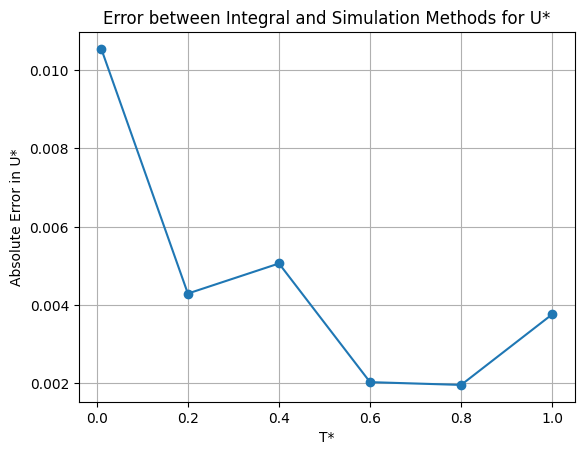

In [ ]:
error = np.abs(np.array(U_star_integral) - np.array(U_star_simulation))
plt.plot(T_stars, error, marker='o')
plt.xlabel('T*')
plt.ylabel('Absolute Error in U*')
plt.title('Error between Integral and Simulation Methods for U*')
plt.grid()
plt.show()

## Actual POT E after adding the LRC term

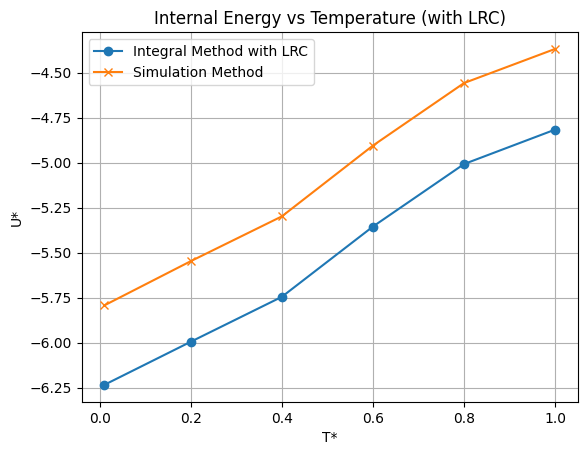

In [ ]:
U_star_integral_LRC = []
for i in range(len(result)):
    g_r = result[i].g_avg
    r = result[i].r_centers
    U_star_integral_LRC.append(get_internal_energy(g_r, r, rho_star, sim, LRC=True))

plt.plot(T_stars, U_star_integral_LRC, marker='o', label='Integral Method with LRC')
plt.plot(T_stars, U_star_simulation, marker='x', label='Simulation Method')
plt.xlabel('T*')
plt.ylabel('U*')
plt.title('Internal Energy vs Temperature (with LRC)')
plt.legend()
plt.grid()
plt.show()

## Structure factor

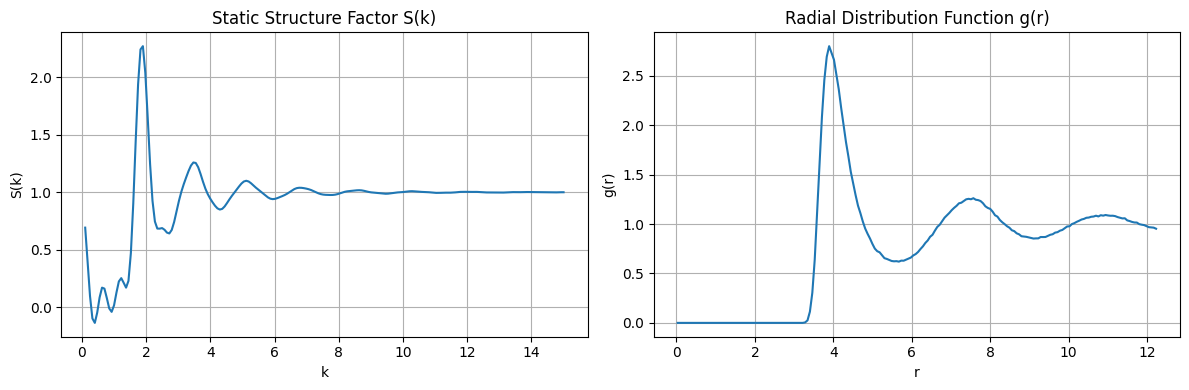

In [ ]:
g_r = result[-1].g_avg
r = result[-1].r_centers * SimulationConfig.sigma
rho = SimulationConfig.rho_star / SimulationConfig.sigma**3

def get_structure_factor(g_r, r, rho):
    k = np.linspace(0.1, 15, 200)
    S_k = []
    for k_val in k:
        integrand = (g_r - 1) * r**2 * np.sinc(k_val * r / np.pi)
        S_k.append(1 + 4 * np.pi * rho * sp.integrate.simpson(integrand, x=r))
    return k,S_k

k, S_k = get_structure_factor(g_r, r, rho)

fig,axs = plt.subplots(1,2, figsize=(12, 4))
axs[0].plot(k, S_k)
axs[0].set_xlabel('k')
axs[0].set_ylabel('S(k)')
axs[0].set_title('Static Structure Factor S(k)')
axs[0].grid()

axs[1].plot(r, g_r)
axs[1].set_xlabel('r')
axs[1].set_ylabel('g(r)')
axs[1].set_title('Radial Distribution Function g(r)')
axs[1].grid()
plt.tight_layout()
plt.show()

## VACF

In [ ]:
def compute_velocity_autocorrelation(vel):

    velocities = vel.copy() 
    velocities_padded = np.append(velocities, np.zeros_like(velocities), axis=0)  

    vel_fft = np.fft.fft(velocities_padded, axis=0)
    power_spectrum = vel_fft * np.conj(vel_fft) 

    vacf_raw = np.fft.ifft(power_spectrum, axis=0).real
    vacf_raw = vacf_raw[:4000]

    weights = np.arange(4000, 0, -1)
    vacf_weighted = vacf_raw / weights[:, None, None]

    N = velocities.shape[1]
    vacf = np.sum(vacf_weighted, axis=(1, 2))/N
    vacf_normalized = vacf / vacf[0]

    return vacf, vacf_normalized

def calculate_diffusion_coefficient_vacf(vacf):
    integration = sp.integrate.simpson(vacf, dx=SimulationConfig.dt)
    D = 1/3.0 * integration
    return D

For T* = 0.01:
Diffusion Coefficient D*: 0.00013007248355414262
Diffusion coefficient through Einstein relation: -1.0220912930503066e-06
For T* = 0.20:
Diffusion Coefficient D*: 0.0018685204590095615
Diffusion coefficient through Einstein relation: 1.2532068891630908e-05
For T* = 0.40:
Diffusion Coefficient D*: 0.0016843807142494446
Diffusion coefficient through Einstein relation: 3.637192533998698e-05
For T* = 0.60:
Diffusion Coefficient D*: 0.009583584477229427
Diffusion coefficient through Einstein relation: 0.01607976158265415
For T* = 0.80:
Diffusion Coefficient D*: 0.03812702279705413
Diffusion coefficient through Einstein relation: 0.037649866361978916
For T* = 1.00:
Diffusion Coefficient D*: 0.04260356943910568
Diffusion coefficient through Einstein relation: 0.04086340497663913


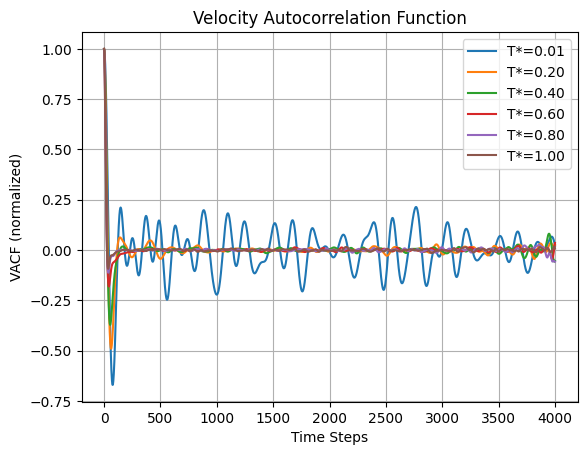

In [ ]:
for i in range(len(result)):
    vel = result[i].velocities
    vacf, vacf_normalized = compute_velocity_autocorrelation(vel)
    plt.plot(vacf_normalized, label=f'T*={result[i].T_star:.2f}')
    D = calculate_diffusion_coefficient_vacf(vacf)
    print("For T* = {:.2f}:".format(result[i].T_star))
    print(f"Diffusion Coefficient D*: {D}")
    _,_,D_msd = MDSimulation._calculate_diffusion_coefficient(result[i].msd,result[i].time_step)
    print(f"Diffusion coefficient through Einstein relation: {D_msd}")

plt.xlabel('Time Steps')
plt.ylabel('VACF (normalized)')
plt.title('Velocity Autocorrelation Function')
plt.legend()
plt.grid()
plt.show()